# exp006 - visual temporal localisation on the larger natural split

same basic visual temporal idea as exp004, but this time i start from the full usable validation manifest and make a new group-disjoint 70/15/15 split without class/condition balancing.

main flow:

```text
full usable validation manifest
-> add modality labels + clip_group
-> drop visually-fake rows with no usable visual segments
-> group-disjoint 70/15/15 split
-> sample 64 frames
-> frozen convnext-base -> [64, 1024]
-> per-frame linear head
-> frame / clip / sampled-grid localisation analysis
```


## method reminder

visual_fake controls the temporal target:

- `real` and `real_video_fake_audio` stay visually real at all 64 sampled positions
- `fake_video_real_audio` and `fake_video_fake_audio` use `visual_fake_segments`

the temporal head is only layernorm + linear on each frozen convnext frame feature, so neighbouring frames are not explicitly modelled.

In [3]:
# imports + reproducibility

from pathlib import Path
from datetime import datetime
import json
import shutil
import zipfile
import hashlib
import ast
import random
import time
import gc

import numpy as np
import pandas as pd

import cv2
cv2.setNumThreads(0)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import convnext_base, ConvNeXt_Base_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import FileLink, display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
# longer helpers are split by purpose for exp006
from utils.data_utils import (
    find_manifest,
    load_metadata_json_if_available,
    enrich_with_metadata_if_needed,
    add_modality_labels,
    segment_count,
    group_disjoint_random_split,
    group_overlap_summary,
)

from utils.feature_utils import (
    ConvNeXtFrameFeatureExtractor,
    make_feature_loader,
    extract_temporal_feature_shards,
)

from utils.temporal_utils import (
    get_shard_paths,
    compute_frame_label_counts,
    TemporalLinearHead,
    iter_temporal_minibatches,
    safe_auc,
    evaluate_temporal_model,
    plot_temporal_examples,
)


Torch: 2.3.1+cu121
CUDA available: True
GPU: NVIDIA A40


In [4]:
# paths used on the qmul jupyter environment

PROJECT_ROOT = Path("/home/jovyan/MSC_PROJECT")
DATA_DIR = PROJECT_ROOT / "data" / "avdeepfake1mpp"
MANIFEST_DIR = DATA_DIR / "manifests"
EXPORTS_DIR = PROJECT_ROOT / "exports"
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_FILENAME = "exp006_visual_temporal_fullval.ipynb"
NOTEBOOK_PATH = PROJECT_ROOT / NOTEBOOK_FILENAME

PATH_COL = "path"
RELATIVE_PATH_COL = "relative_path"
CONDITION_COL = "condition"
BINARY_LABEL_COL = "binary_label"

SEGMENT_COL = "visual_fake_segments"
AUDIO_SEGMENT_COL = "audio_fake_segments"

MANIFEST_CANDIDATES = [
    MANIFEST_DIR / "usable_multimodal_val_labelled_manifest.csv",
    MANIFEST_DIR / "usable_multimodal_val_manifest.csv",
    MANIFEST_DIR / "val_labelled_manifest.csv",
]

METADATA_JSON_CANDIDATES = [
    DATA_DIR / "val_metadata.json",
    PROJECT_ROOT / "val_metadata.json",
    Path("/mnt/data/val_metadata.json"),
]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MANIFEST_DIR:", MANIFEST_DIR)
print("EXPECTED NOTEBOOK_PATH:", NOTEBOOK_PATH)
print("Notebook exists at expected path:", NOTEBOOK_PATH.exists())

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"PROJECT_ROOT not found: {PROJECT_ROOT}")

PROJECT_ROOT: /home/jovyan/MSC_PROJECT
DATA_DIR: /home/jovyan/MSC_PROJECT/data/avdeepfake1mpp
MANIFEST_DIR: /home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/manifests
EXPECTED NOTEBOOK_PATH: /home/jovyan/MSC_PROJECT/exp006_visual_temporal_fullval.ipynb
Notebook exists at expected path: True


## experiment config

In [5]:
# main exp006 settings

EXPERIMENT_ID = "exp006"
EXPERIMENT_NAME = "visual_temporal_fullval"
RUN_NAME = f"{EXPERIMENT_ID}_{EXPERIMENT_NAME}"

MODEL_NAME = "convnext_base"
NUM_FRAMES = 64
IMAGE_SIZE = 224

# larger extraction than exp004; final run used feature batch size 32
FEATURE_BATCH_SIZE = 32
NUM_WORKERS = 8
PREFETCH_FACTOR = 1
PIN_MEMORY = False

TEMPORAL_BATCH_SIZE = 32
TEMPORAL_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DEFAULT_THRESHOLD = 0.5

# natural full-validation split - no balancing/downsampling
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# visually-fake rows without usable visual segments are dropped
MISSING_VISUAL_SEGMENT_POLICY = "drop"

# keep visually-real metadata conflicts as negatives; audio-only fakes should stay visual-real
KEEP_VISUAL_REAL_CONFLICTS_AS_NEGATIVE = True

POS_WEIGHT_CAP = 20.0

EXPERIMENT_CONFIG = {
    "run_name": RUN_NAME,
    "task": "visual_temporal_localisation_full_validation_set",
    "model": "Frozen ConvNeXt-Base frame encoder + per-frame linear head",
    "dataset": "AV-Deepfake1M++ validation subset",
    "split_type": "group_disjoint_fullval_natural_distribution",
    "sampling": "no balancing, no downsampling",
    "target": "frame-level visual_fake labels from condition + visual_fake_segments",
    "segment_col": SEGMENT_COL,
    "num_frames": NUM_FRAMES,
    "image_size": IMAGE_SIZE,
    "feature_batch_size": FEATURE_BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "prefetch_factor": PREFETCH_FACTOR,
    "pin_memory": PIN_MEMORY,
    "temporal_batch_size": TEMPORAL_BATCH_SIZE,
    "temporal_epochs": TEMPORAL_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "default_threshold": DEFAULT_THRESHOLD,
    "train_frac": TRAIN_FRAC,
    "val_frac": VAL_FRAC,
    "test_frac": TEST_FRAC,
    "missing_visual_segment_policy": MISSING_VISUAL_SEGMENT_POLICY,
    "keep_visual_real_conflicts_as_negative": KEEP_VISUAL_REAL_CONFLICTS_AS_NEGATIVE,
    "pos_weight_cap": POS_WEIGHT_CAP,
    "seed": SEED,
}

EXPERIMENT_CONFIG

{'run_name': 'exp006_visual_temporal_fullval',
 'task': 'visual_temporal_localisation_full_validation_set',
 'model': 'Frozen ConvNeXt-Base frame encoder + per-frame linear head',
 'dataset': 'AV-Deepfake1M++ validation subset',
 'split_type': 'group_disjoint_fullval_natural_distribution',
 'sampling': 'no balancing, no downsampling',
 'target': 'frame-level visual_fake labels from condition + visual_fake_segments',
 'segment_col': 'visual_fake_segments',
 'num_frames': 64,
 'image_size': 224,
 'feature_batch_size': 32,
 'num_workers': 8,
 'prefetch_factor': 1,
 'pin_memory': False,
 'temporal_batch_size': 32,
 'temporal_epochs': 20,
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'default_threshold': 0.5,
 'train_frac': 0.7,
 'val_frac': 0.15,
 'test_frac': 0.15,
 'missing_visual_segment_policy': 'drop',
 'keep_visual_real_conflicts_as_negative': True,
 'pos_weight_cap': 20.0,
 'seed': 42}

In [6]:
# create the run folders and save the config

def setup_experiment_short(project_root, run_name, config):
    """create the run folders and save config.json for this experiment."""
    project_root = Path(project_root)
    run_dir = project_root / "experiments" / run_name

    dirs = {
        "run": run_dir,
        "manifests": run_dir / "manifests",
        "results": run_dir / "results",
        "checkpoints": run_dir / "checkpoints",
        "plots": run_dir / "plots",
        "notebook": run_dir / "notebook",
        "features": run_dir / "features",
    }

    for d in dirs.values():
        d.mkdir(parents=True, exist_ok=True)

    config = dict(config)
    config["created_at"] = datetime.now().isoformat(timespec="seconds")

    config_path = run_dir / "config.json"
    with open(config_path, "w") as f:
        json.dump(config, f, indent=4)

    print("Experiment folder:", run_dir)
    print("Config saved:", config_path)

    return dirs


RUN_DIRS = setup_experiment_short(PROJECT_ROOT, RUN_NAME, EXPERIMENT_CONFIG)

RUN_MANIFEST_DIR = RUN_DIRS["manifests"]
RESULTS_DIR = RUN_DIRS["results"]
CHECKPOINT_DIR = RUN_DIRS["checkpoints"]
PLOTS_DIR = RUN_DIRS["plots"]
FEATURE_DIR = RUN_DIRS["features"]

TEMPORAL_FEATURE_DIR = FEATURE_DIR / f"visual_temporal_{MODEL_NAME}_{NUM_FRAMES}f"
TEMPORAL_FEATURE_DIR.mkdir(parents=True, exist_ok=True)

print("RUN_NAME:", RUN_NAME)
print("TEMPORAL_FEATURE_DIR:", TEMPORAL_FEATURE_DIR)

Experiment folder: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval
Config saved: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/config.json
RUN_NAME: exp006_visual_temporal_fullval
TEMPORAL_FEATURE_DIR: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/features/visual_temporal_convnext_base_64f


## load the full usable validation manifest

unlike exp004, this experiment starts before the train/val/test split. the full usable manifest is loaded first, then filtered and split below.

In [7]:
# find the usable full-validation manifest and load it

manifest_path = find_manifest(MANIFEST_CANDIDATES)
full_df = pd.read_csv(manifest_path)

print("Using manifest:", manifest_path)
print("Full manifest shape:", full_df.shape)
display(full_df.head())
print("Columns:")
print(full_df.columns.tolist())

Using manifest: /home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/manifests/usable_multimodal_val_labelled_manifest.csv
Full manifest shape: (76928, 25)


,path,relative_path,filename,file_size_bytes,file,original,split,modify_type,audio_model,fake_segments,...,has_audio_stream,audio_decodable,audio_codec,sample_rate,channels,audio_duration,binary_label,visual_fake,audio_fake,condition
0,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4,fake_video_fake_audio.mp4,1524347,lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,both_modified,yourtts,"[[0.65, 1.15], [2.03, 2.25]]",...,True,True,pcm_s16le,16000.0,1.0,18.176000,1,1,1,fake_video_fake_audio
1,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/fake_video_real_audio.mp4,fake_video_real_audio.mp4,1517990,lrs3/1Hok1iGFNSk/00004/fake_video_real_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,visual_modified,NaN,"[[0.65, 0.97], [1.851, 2.151]]",...,True,True,pcm_s16le,16000.0,1.0,18.048000,1,1,0,fake_video_real_audio
2,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/real.mp4,real.mp4,2223274,lrs3/1Hok1iGFNSk/00004/real.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,real,NaN,[],...,True,True,pcm_s16le,16000.0,1.0,17.920000,0,0,0,real
3,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/real_video_fake_audio.mp4,real_video_fake_audio.mp4,1527373,lrs3/1Hok1iGFNSk/00004/real_video_fake_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,audio_modified,yourtts,"[[0.65, 1.15], [2.03, 2.25]]",...,True,True,pcm_s16le,16000.0,1.0,18.176000,1,0,1,real_video_fake_audio
4,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/2YPHJdq5QWM/00001/00001_p1.mp4,00001_p1.mp4,2450165,lrs3/2YPHJdq5QWM/00001/00001_p1.mp4,NaN,val,real,NaN,[],...,True,True,pcm_s16le,16000.0,1.0,50.596313,0,0,0,real


Columns:
['path', 'relative_path', 'filename', 'file_size_bytes', 'file', 'original', 'split', 'modify_type', 'audio_model', 'fake_segments', 'audio_fake_segments', 'visual_fake_segments', 'video_frames', 'audio_frames', 'video_model', 'has_audio_stream', 'audio_decodable', 'audio_codec', 'sample_rate', 'channels', 'audio_duration', 'binary_label', 'visual_fake', 'audio_fake', 'condition']


In [8]:
# only use the metadata json if useful fields are missing from the manifest

metadata_df, metadata_path = load_metadata_json_if_available(METADATA_JSON_CANDIDATES)
full_df = enrich_with_metadata_if_needed(full_df, metadata_df, RELATIVE_PATH_COL)

print("Full manifest after enrichment:", full_df.shape)
print("visual_fake_segments present:", SEGMENT_COL in full_df.columns)
display(full_df.head())

No metadata JSON found. Continuing with manifest columns.
Full manifest after enrichment: (76928, 25)
visual_fake_segments present: True


,path,relative_path,filename,file_size_bytes,file,original,split,modify_type,audio_model,fake_segments,...,has_audio_stream,audio_decodable,audio_codec,sample_rate,channels,audio_duration,binary_label,visual_fake,audio_fake,condition
0,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4,fake_video_fake_audio.mp4,1524347,lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,both_modified,yourtts,"[[0.65, 1.15], [2.03, 2.25]]",...,True,True,pcm_s16le,16000.0,1.0,18.176000,1,1,1,fake_video_fake_audio
1,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/fake_video_real_audio.mp4,fake_video_real_audio.mp4,1517990,lrs3/1Hok1iGFNSk/00004/fake_video_real_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,visual_modified,NaN,"[[0.65, 0.97], [1.851, 2.151]]",...,True,True,pcm_s16le,16000.0,1.0,18.048000,1,1,0,fake_video_real_audio
2,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/real.mp4,real.mp4,2223274,lrs3/1Hok1iGFNSk/00004/real.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,real,NaN,[],...,True,True,pcm_s16le,16000.0,1.0,17.920000,0,0,0,real
3,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/real_video_fake_audio.mp4,real_video_fake_audio.mp4,1527373,lrs3/1Hok1iGFNSk/00004/real_video_fake_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,audio_modified,yourtts,"[[0.65, 1.15], [2.03, 2.25]]",...,True,True,pcm_s16le,16000.0,1.0,18.176000,1,0,1,real_video_fake_audio
4,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/2YPHJdq5QWM/00001/00001_p1.mp4,00001_p1.mp4,2450165,lrs3/2YPHJdq5QWM/00001/00001_p1.mp4,NaN,val,real,NaN,[],...,True,True,pcm_s16le,16000.0,1.0,50.596313,0,0,0,real


In [9]:
# add modality labels + clip groups, then remove rows whose video path is missing locally

required_cols = [PATH_COL, CONDITION_COL]
missing_required = [c for c in required_cols if c not in full_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

full_df = add_modality_labels(full_df, CONDITION_COL, RELATIVE_PATH_COL, PATH_COL)

# Keep only files that exist locally.
exists_mask = full_df[PATH_COL].apply(lambda p: Path(str(p)).exists())
missing_count = int((~exists_mask).sum())
print("Rows with missing local video paths:", missing_count)

if missing_count > 0:
    missing_path = RESULTS_DIR / "missing_video_paths_sample.csv"
    full_df.loc[~exists_mask].head(100).to_csv(missing_path, index=False)
    print("Saved missing path sample:", missing_path)

full_df = full_df[exists_mask].copy().reset_index(drop=True)

print("Full usable rows:", len(full_df))
print("\nBinary label distribution:")
print(full_df["binary_label"].value_counts(dropna=False))

print("\nVisual fake distribution:")
print(full_df["visual_fake"].value_counts(dropna=False))

print("\nCondition distribution:")
print(full_df[CONDITION_COL].value_counts(dropna=False))

display(full_df.head())

Rows with missing local video paths: 0
Full usable rows: 76928

Binary label distribution:
binary_label
1    56907
0    20021
Name: count, dtype: int64

Visual fake distribution:
visual_fake
0    38959
1    37969
Name: count, dtype: int64

Condition distribution:
condition
real                     20021
fake_video_fake_audio    19069
real_video_fake_audio    18938
fake_video_real_audio    18900
Name: count, dtype: int64


,path,relative_path,filename,file_size_bytes,file,original,split,modify_type,audio_model,fake_segments,...,audio_decodable,audio_codec,sample_rate,channels,audio_duration,binary_label,visual_fake,audio_fake,condition,clip_group
0,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4,fake_video_fake_audio.mp4,1524347,lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,both_modified,yourtts,"[[0.65, 1.15], [2.03, 2.25]]",...,True,pcm_s16le,16000.0,1.0,18.176000,1,1,1,fake_video_fake_audio,lrs3/1Hok1iGFNSk/00004
1,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/fake_video_real_audio.mp4,fake_video_real_audio.mp4,1517990,lrs3/1Hok1iGFNSk/00004/fake_video_real_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,visual_modified,NaN,"[[0.65, 0.97], [1.851, 2.151]]",...,True,pcm_s16le,16000.0,1.0,18.048000,1,1,0,fake_video_real_audio,lrs3/1Hok1iGFNSk/00004
2,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/real.mp4,real.mp4,2223274,lrs3/1Hok1iGFNSk/00004/real.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,real,NaN,[],...,True,pcm_s16le,16000.0,1.0,17.920000,0,0,0,real,lrs3/1Hok1iGFNSk/00004
3,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/real_video_fake_audio.mp4,real_video_fake_audio.mp4,1527373,lrs3/1Hok1iGFNSk/00004/real_video_fake_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,audio_modified,yourtts,"[[0.65, 1.15], [2.03, 2.25]]",...,True,pcm_s16le,16000.0,1.0,18.176000,1,0,1,real_video_fake_audio,lrs3/1Hok1iGFNSk/00004
4,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/2YPHJdq5QWM/00001/00001_p1.mp4,00001_p1.mp4,2450165,lrs3/2YPHJdq5QWM/00001/00001_p1.mp4,NaN,val,real,NaN,[],...,True,pcm_s16le,16000.0,1.0,50.596313,0,0,0,real,lrs3/2YPHJdq5QWM/00001


## visual segment labels

only `visual_fake_segments` is used for the visual temporal target.

for visually-real conditions the sampled frame labels stay all zero even if the metadata happens to contain a strange visual segment value.

In [11]:
# audit missing visual labels + visually-real rows that still contain visual segment metadata

full_df["visual_segment_count"] = full_df.apply(lambda row: segment_count(row, SEGMENT_COL), axis=1)
full_df["has_visual_segment_annotation"] = (full_df["visual_segment_count"] > 0).astype(int)

# Conflict types:
# 1. visually fake but no visual segments: cannot supervise localisation cleanly.
# 2. visually real but has visual segments: keep as visual-real negatives but audit.
full_df["visual_fake_missing_segments"] = ((full_df["visual_fake"] == 1) & (full_df["visual_segment_count"] == 0)).astype(int)
full_df["visual_real_with_segments"] = ((full_df["visual_fake"] == 0) & (full_df["visual_segment_count"] > 0)).astype(int)

conflict_summary = (
    full_df.groupby(CONDITION_COL)
    .agg(
        n_rows=("visual_fake", "size"),
        visual_fake=("visual_fake", "first"),
        rows_with_visual_segments=("has_visual_segment_annotation", "sum"),
        visually_fake_missing_segments=("visual_fake_missing_segments", "sum"),
        visually_real_with_segments=("visual_real_with_segments", "sum"),
        mean_visual_segments=("visual_segment_count", "mean"),
    )
    .reset_index()
)

conflict_path = RESULTS_DIR / "visual_label_conflict_audit.csv"
conflict_summary.to_csv(conflict_path, index=False)

display(conflict_summary)
print("Saved:", conflict_path)

display(full_df.loc[full_df["visual_real_with_segments"] == 1, [CONDITION_COL, "visual_fake", "audio_fake", SEGMENT_COL]].head())

,condition,n_rows,visual_fake,rows_with_visual_segments,visually_fake_missing_segments,visually_real_with_segments,mean_visual_segments
0,fake_video_fake_audio,19069,1,19069,0,0,1.358383
1,fake_video_real_audio,18900,1,18900,0,0,1.359524
2,real,20021,0,0,0,0,0.000000
3,real_video_fake_audio,18938,0,639,0,639,0.033742


Saved: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/results/visual_label_conflict_audit.csv


,condition,visual_fake,audio_fake,visual_fake_segments
26,real_video_fake_audio,0,1,"[[0.129, 0.59]]"
36,real_video_fake_audio,0,1,"[[0.87, 1.01]]"
37,real_video_fake_audio,0,1,"[[0.87, 1.01]]"
38,real_video_fake_audio,0,1,"[[0.87, 1.01]]"
39,real_video_fake_audio,0,1,"[[0.87, 1.01]]"


In [12]:
# apply the missing-segment policy before making the split

before = len(full_df)

if MISSING_VISUAL_SEGMENT_POLICY == "drop":
    # only drop visually-fake rows that have no usable visual temporal labels
    full_df = full_df[full_df["visual_fake_missing_segments"] == 0].copy().reset_index(drop=True)
elif MISSING_VISUAL_SEGMENT_POLICY == "all_fake":
    # kept and handled by the dataset later
    pass
elif MISSING_VISUAL_SEGMENT_POLICY == "keep_zero":
    # kept and handled by the dataset later
    pass
else:
    raise ValueError(f"Unknown MISSING_VISUAL_SEGMENT_POLICY: {MISSING_VISUAL_SEGMENT_POLICY}")

after = len(full_df)

print("Rows before filtering:", before)
print("Rows after filtering:", after)
print("Rows dropped:", before - after)

print("\nFinal condition distribution:")
print(full_df[CONDITION_COL].value_counts(dropna=False))

print("\nFinal binary label distribution:")
print(full_df["binary_label"].value_counts(dropna=False))

print("\nFinal visual_fake distribution:")
print(full_df["visual_fake"].value_counts(dropna=False))

Rows before filtering: 76928
Rows after filtering: 76928
Rows dropped: 0

Final condition distribution:
condition
real                     20021
fake_video_fake_audio    19069
real_video_fake_audio    18938
fake_video_real_audio    18900
Name: count, dtype: int64

Final binary label distribution:
binary_label
1    56907
0    20021
Name: count, dtype: int64

Final visual_fake distribution:
visual_fake
0    38959
1    37969
Name: count, dtype: int64


## make the natural group-disjoint split

unique clip groups are shuffled with seed 42 and split approximately 70/15/15.

there is no balancing here, so the row/condition proportions come from the filtered full-validation manifest rather than being forced to match exp004.

In [13]:
# create the seeded group-disjoint split and save the three manifests

train_df, val_df, test_df = group_disjoint_random_split(
    full_df,
    group_col="clip_group",
    train_frac=TRAIN_FRAC,
    val_frac=VAL_FRAC,
    test_frac=TEST_FRAC,
    seed=SEED,
)

train_csv = RUN_MANIFEST_DIR / "train.csv"
val_csv = RUN_MANIFEST_DIR / "val.csv"
test_csv = RUN_MANIFEST_DIR / "test.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain condition distribution:")
print(train_df[CONDITION_COL].value_counts(dropna=False))

print("\nVal condition distribution:")
print(val_df[CONDITION_COL].value_counts(dropna=False))

print("\nTest condition distribution:")
print(test_df[CONDITION_COL].value_counts(dropna=False))

Train: (53709, 30)
Val: (11628, 30)
Test: (11591, 30)

Train condition distribution:
condition
real                     13948
fake_video_fake_audio    13345
real_video_fake_audio    13261
fake_video_real_audio    13155
Name: count, dtype: int64

Val condition distribution:
condition
real                     3086
fake_video_real_audio    2874
fake_video_fake_audio    2834
real_video_fake_audio    2834
Name: count, dtype: int64

Test condition distribution:
condition
real                     2987
fake_video_fake_audio    2890
fake_video_real_audio    2871
real_video_fake_audio    2843
Name: count, dtype: int64


In [14]:
# save the final split counts + confirm there is no clip_group overlap

split_summary = {
    "run_name": RUN_NAME,
    "source_manifest_path": str(manifest_path),
    "metadata_path_used": str(metadata_path) if metadata_path is not None else None,
    "split_type": "group_disjoint_random_fullval_no_balancing",
    "train_frac": TRAIN_FRAC,
    "val_frac": VAL_FRAC,
    "test_frac": TEST_FRAC,
    "missing_visual_segment_policy": MISSING_VISUAL_SEGMENT_POLICY,
    "rows_total_after_filtering": len(full_df),
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "full_condition_counts": full_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "train_condition_counts": train_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "val_condition_counts": val_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "test_condition_counts": test_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "full_binary_label_counts": full_df["binary_label"].value_counts(dropna=False).to_dict(),
    "train_binary_label_counts": train_df["binary_label"].value_counts(dropna=False).to_dict(),
    "val_binary_label_counts": val_df["binary_label"].value_counts(dropna=False).to_dict(),
    "test_binary_label_counts": test_df["binary_label"].value_counts(dropna=False).to_dict(),
    "full_visual_fake_counts": full_df["visual_fake"].value_counts(dropna=False).to_dict(),
    "train_visual_fake_counts": train_df["visual_fake"].value_counts(dropna=False).to_dict(),
    "val_visual_fake_counts": val_df["visual_fake"].value_counts(dropna=False).to_dict(),
    "test_visual_fake_counts": test_df["visual_fake"].value_counts(dropna=False).to_dict(),
    **group_overlap_summary(train_df, val_df, test_df),
}

split_summary_path = RUN_DIRS["run"] / "split_summary.json"
with open(split_summary_path, "w") as f:
    json.dump(split_summary, f, indent=4)

split_summary

{'run_name': 'exp006_visual_temporal_fullval',
 'source_manifest_path': '/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/manifests/usable_multimodal_val_labelled_manifest.csv',
 'metadata_path_used': None,
 'split_type': 'group_disjoint_random_fullval_no_balancing',
 'train_frac': 0.7,
 'val_frac': 0.15,
 'test_frac': 0.15,
 'missing_visual_segment_policy': 'drop',
 'rows_total_after_filtering': 76928,
 'train_rows': 53709,
 'val_rows': 11628,
 'test_rows': 11591,
 'full_condition_counts': {'real': 20021,
  'fake_video_fake_audio': 19069,
  'real_video_fake_audio': 18938,
  'fake_video_real_audio': 18900},
 'train_condition_counts': {'real': 13948,
  'fake_video_fake_audio': 13345,
  'real_video_fake_audio': 13261,
  'fake_video_real_audio': 13155},
 'val_condition_counts': {'real': 3086,
  'fake_video_real_audio': 2874,
  'fake_video_fake_audio': 2834,
  'real_video_fake_audio': 2834},
 'test_condition_counts': {'real': 2987,
  'fake_video_fake_audio': 2890,
  'fake_video_real_audio': 28

## rough storage check

this was just the estimate i used before extracting the larger 64-frame feature cache.

In [15]:
# rough float16 feature-storage estimate for the filtered full dataset

estimated_feature_bytes = len(full_df) * NUM_FRAMES * 1024 * 2
estimated_feature_gb = estimated_feature_bytes / 1024**3

print(f"Estimated temporal feature storage: {estimated_feature_gb:.2f} GB")
print("This excludes small overhead from labels, times, and shard metadata.")
print("Final run continued with NUM_FRAMES=64.")

Estimated temporal feature storage: 9.39 GB
This excludes small overhead from labels, times, and shard metadata.
If storage is tight, stop now and set NUM_FRAMES=32 before extraction.


## frozen temporal features

each video keeps the 64 separate convnext frame features:

```text
features      [B, 64, 1024]
frame_labels  [B, 64]
frame_times   [B, 64]
video_labels  [B]
indices       [B]
```

the cached features are float16, while the temporal head later converts them back to float32 for training.

In [18]:
# build the video loaders used for frozen feature extraction

feature_loader_args = dict(
    num_frames=NUM_FRAMES,
    image_size=IMAGE_SIZE,
    feature_batch_size=FEATURE_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    prefetch_factor=PREFETCH_FACTOR,
    path_col=PATH_COL,
    missing_visual_segment_policy=MISSING_VISUAL_SEGMENT_POLICY,
    segment_col=SEGMENT_COL,
)

train_feature_dataset, train_feature_loader = make_feature_loader(
    train_csv,
    **feature_loader_args,
)

val_feature_dataset, val_feature_loader = make_feature_loader(
    val_csv,
    **feature_loader_args,
)

test_feature_dataset, test_feature_loader = make_feature_loader(
    test_csv,
    **feature_loader_args,
)

print("Train samples:", len(train_feature_dataset))
print("Val samples:", len(val_feature_dataset))
print("Test samples:", len(test_feature_dataset))
print("Train batches:", len(train_feature_loader))
print("Val batches:", len(val_feature_loader))
print("Test batches:", len(test_feature_loader))


Train samples: 53709
Val samples: 11628
Test samples: 11591
Train batches: 1679
Val batches: 364
Test batches: 363


In [19]:
# one batch check before doing the expensive full feature extraction

print("Trying one temporal feature batch...")

start = time.time()
frames, frame_labels, frame_times, video_labels, indices = next(iter(train_feature_loader))
elapsed = time.time() - start

print("Frames:", frames.shape)
print("Frame labels:", frame_labels.shape)
print("Frame times:", frame_times.shape)
print("Video labels:", video_labels.shape)
print("Indices:", indices.shape)
print("Positive frame labels in batch:", float(frame_labels.sum().item()))
print(f"Elapsed: {elapsed:.2f}s")

Trying one temporal feature batch...
Frames: torch.Size([32, 64, 3, 224, 224])
Frame labels: torch.Size([32, 64])
Frame times: torch.Size([32, 64])
Video labels: torch.Size([32])
Indices: torch.Size([32])
Positive frame labels in batch: 29.0
Elapsed: 82.61s


In [21]:
# run/reuse frozen convnext feature extraction for train, val and test

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

frame_encoder = ConvNeXtFrameFeatureExtractor().to(device)
frame_encoder.eval()

train_shard_manifest = extract_temporal_feature_shards(
    frame_encoder,
    train_feature_loader,
    "train",
    TEMPORAL_FEATURE_DIR,
    device,
    MODEL_NAME,
    NUM_FRAMES,
    IMAGE_SIZE,
)

val_shard_manifest = extract_temporal_feature_shards(
    frame_encoder,
    val_feature_loader,
    "val",
    TEMPORAL_FEATURE_DIR,
    device,
    MODEL_NAME,
    NUM_FRAMES,
    IMAGE_SIZE,
)

test_shard_manifest = extract_temporal_feature_shards(
    frame_encoder,
    test_feature_loader,
    "test",
    TEMPORAL_FEATURE_DIR,
    device,
    MODEL_NAME,
    NUM_FRAMES,
    IMAGE_SIZE,
)

display(train_shard_manifest.head())
display(val_shard_manifest.head())
display(test_shard_manifest.head())

Device: cuda


extract train:   0%|          | 0/1679 [01:30<?, ?it/s, videos=32, pos=29, gpu=5.3G]

train | shard 0/1679 | videos=32


extract train:   1%|          | 10/1679 [02:17<3:44:15,  8.06s/it, videos=352, pos=387, gpu=28.1G]

train | shard 10/1679 | videos=352


...

extract test: 100%|██████████| 363/363 [47:49<00:00,  7.90s/it, videos=11552, pos=19247, gpu=28.1G]


test: saved 11591 videos across 363 shards
test: elapsed 47.82 min
Manifest: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/features/visual_temporal_convnext_base_64f/test/shard_manifest.csv


,split,shard_idx,path,n_videos,num_frames,feature_dim,positive_frames,total_frames,size_mb,elapsed_total_sec
0,train,0,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,29.0,2048,4.010666,11414.780829
1,train,1,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,23.0,2048,4.010666,11414.780829
2,train,2,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,54.0,2048,4.010666,11414.780829
3,train,3,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,0.0,2048,4.010666,11414.780829
4,train,4,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,0.0,2048,4.010666,11414.780829


,split,shard_idx,path,n_videos,num_frames,feature_dim,positive_frames,total_frames,size_mb,elapsed_total_sec
0,val,0,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,36.0,2048,4.010666,2698.920173
1,val,1,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,15.0,2048,4.010666,2698.920173
2,val,2,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,52.0,2048,4.010666,2698.920173
3,val,3,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,83.0,2048,4.010666,2698.920173
4,val,4,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,60.0,2048,4.010666,2698.920173


,split,shard_idx,path,n_videos,num_frames,feature_dim,positive_frames,total_frames,size_mb,elapsed_total_sec
0,test,0,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,30.0,2048,4.010666,2869.422425
1,test,1,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,26.0,2048,4.010666,2869.422425
2,test,2,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,38.0,2048,4.010666,2869.422425
3,test,3,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,40.0,2048,4.010666,2869.422425
4,test,4,/home/jovyan/MSC_PROJECT/experiments/exp006_vi...,32,64,1024,61.0,2048,4.010666,2869.422425


## train the frame head

same simple head idea as exp004:

```text
1024-d frozen frame feature
-> layernorm
-> linear 1024 -> 1
-> visual-fake logit
```

each sampled frame is scored independently. the main difference in this experiment is the larger natural-distribution split, not a different temporal model.

In [22]:
# load the saved feature shard lists and count the training-frame imbalance

train_shard_paths = get_shard_paths(TEMPORAL_FEATURE_DIR, "train")
val_shard_paths = get_shard_paths(TEMPORAL_FEATURE_DIR, "val")
test_shard_paths = get_shard_paths(TEMPORAL_FEATURE_DIR, "test")

print("Train shards:", len(train_shard_paths))
print("Val shards:", len(val_shard_paths))
print("Test shards:", len(test_shard_paths))


frame_count_summary = compute_frame_label_counts(train_shard_paths)
frame_count_summary

Train shards: 1679
Val shards: 364
Test shards: 363


{'positive_frames': 88132.0,
 'negative_frames': 3349244.0,
 'total_frames': 3437376.0,
 'positive_rate': 0.025639324880373866,
 'negative_rate': 0.9743606751196261}

In [23]:
# bce positive-class weight based on the sampled training-frame imbalance

positive = frame_count_summary["positive_frames"]
negative = frame_count_summary["negative_frames"]

if positive <= 0:
    raise ValueError("No positive frame labels found. Check visual_fake_segments parsing and filtering.")

raw_pos_weight = negative / positive
pos_weight_value = min(raw_pos_weight, POS_WEIGHT_CAP)

frame_count_summary["raw_pos_weight"] = raw_pos_weight
frame_count_summary["used_pos_weight"] = pos_weight_value

label_count_path = RESULTS_DIR / "frame_label_count_summary.json"
with open(label_count_path, "w") as f:
    json.dump(frame_count_summary, f, indent=4)

print("Positive frames:", positive)
print("Negative frames:", negative)
print("Positive frame rate:", frame_count_summary["positive_rate"])
print("Raw pos_weight:", raw_pos_weight)
print("Used pos_weight:", pos_weight_value)
print("Saved:", label_count_path)

Positive frames: 88132.0
Negative frames: 3349244.0
Positive frame rate: 0.025639324880373866
Raw pos_weight: 38.002587028548085
Used pos_weight: 20.0
Saved: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/results/frame_label_count_summary.json


In [27]:
# actual 20-epoch temporal-head training loop - best checkpoint uses validation frame auc

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

temporal_model = TemporalLinearHead(input_dim=1024, dropout=0.0).to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
)

optimizer = torch.optim.AdamW(
    temporal_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

best_val_auc = -1
history = []

for epoch in range(1, TEMPORAL_EPOCHS + 1):
    temporal_model.train()

    epoch_loss_sum = 0.0
    epoch_frame_count = 0

    epoch_labels = []
    epoch_probs = []

    progress = tqdm(
        iter_temporal_minibatches(
            train_shard_paths,
            batch_size=TEMPORAL_BATCH_SIZE,
            shuffle_files=True,
            shuffle_within_shard=True,
        ),
        desc=f"temporal train {epoch}/{TEMPORAL_EPOCHS}",
        leave=True,
        mininterval=5,
    )

    step = 0

    for X, y, indices, video_labels in progress:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = temporal_model(X)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            probs = torch.sigmoid(logits)

        epoch_loss_sum += float(loss.item()) * int(y.numel())
        epoch_frame_count += int(y.numel())

        epoch_labels.append(y.detach().cpu().reshape(-1))
        epoch_probs.append(probs.detach().cpu().reshape(-1))

        if step % 50 == 0:
            running_loss = epoch_loss_sum / max(1, epoch_frame_count)
            progress.set_postfix({
                "loss": f"{running_loss:.4f}",
                "gpu": f"{torch.cuda.memory_reserved() / 1024**3:.1f}G" if device == "cuda" else "cpu",
            })
            print(f"epoch {epoch} | step {step} | loss={running_loss:.4f}", flush=True)

        step += 1

        del X, y, logits, loss, probs

    train_y_true = torch.cat(epoch_labels).numpy().astype(int)
    train_y_prob = torch.cat(epoch_probs).numpy()
    train_y_pred = (train_y_prob >= DEFAULT_THRESHOLD).astype(int)

    train_metrics = {
        "loss": epoch_loss_sum / max(1, epoch_frame_count),
        "frame_accuracy": accuracy_score(train_y_true, train_y_pred),
        "frame_balanced_accuracy": balanced_accuracy_score(train_y_true, train_y_pred),
        "frame_f1": f1_score(train_y_true, train_y_pred, zero_division=0),
        "frame_precision": precision_score(train_y_true, train_y_pred, zero_division=0),
        "frame_recall": recall_score(train_y_true, train_y_pred, zero_division=0),
        "frame_auc": safe_auc(train_y_true, train_y_prob),
    }

    val_metrics, _, _, _, _ = evaluate_temporal_model(
        temporal_model,
        val_shard_paths,
        criterion,
        device,
        batch_size=TEMPORAL_BATCH_SIZE,
        threshold=DEFAULT_THRESHOLD,
    )

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }

    history.append(row)
    history_df = pd.DataFrame(history)
    history_path = RESULTS_DIR / "temporal_training_history.csv"
    history_df.to_csv(history_path, index=False)

    print(row)

    if val_metrics["frame_auc"] > best_val_auc:
        best_val_auc = val_metrics["frame_auc"]
        checkpoint_path = CHECKPOINT_DIR / "best_temporal_head.pt"

        torch.save({
            "model_state_dict": temporal_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_metrics": val_metrics,
            "input_dim": 1024,
            "num_frames": NUM_FRAMES,
            "run_name": RUN_NAME,
            "feature_dir": str(TEMPORAL_FEATURE_DIR),
            "threshold": DEFAULT_THRESHOLD,
            "pos_weight": pos_weight_value,
        }, checkpoint_path)

        print("Saved best checkpoint:", checkpoint_path)

    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

Device: cuda


temporal train 1/20: 0it [00:00, ?it/s, loss=1.2894, gpu=0.4G]

epoch 1 | step 0 | loss=1.2894


temporal train 1/20: 41it [00:06,  8.05it/s, loss=0.9819, gpu=0.4G]

epoch 1 | step 50 | loss=0.9819


...

epoch 20 | step 1600 | loss=0.7681


temporal train 20/20: 1616it [03:11,  8.30it/s, loss=0.7680, gpu=0.4G]

epoch 20 | step 1650 | loss=0.7680


temporal train 20/20: 1679it [03:14,  8.63it/s, loss=0.7680, gpu=0.4G]


{'epoch': 20, 'train_loss': 0.7680126164634199, 'train_frame_accuracy': 0.8586523557504329, 'train_frame_balanced_accuracy': 0.6954189253890999, 'train_frame_f1': 0.15957032770296567, 'train_frame_precision': 0.09413591900127147, 'train_frame_recall': 0.5233626832478555, 'train_frame_auc': 0.7929559003262141, 'val_loss': 0.7668897214524723, 'val_frame_accuracy': 0.8861597544719643, 'val_frame_balanced_accuracy': 0.6846947220050009, 'val_frame_f1': 0.1757649462470205, 'val_frame_precision': 0.10797274683241692, 'val_frame_recall': 0.47231372549019607, 'val_frame_auc': 0.795689541568712}


,epoch,train_loss,train_frame_accuracy,train_frame_balanced_accuracy,train_frame_f1,train_frame_precision,train_frame_recall,train_frame_auc,val_loss,val_frame_accuracy,val_frame_balanced_accuracy,val_frame_f1,val_frame_precision,val_frame_recall,val_frame_auc
15,16,0.771173,0.856893,0.692914,0.157082,0.092512,0.520072,0.790572,0.765970,0.898178,0.677066,0.183081,0.115317,0.443974,0.799316
16,17,0.770367,0.856484,0.691926,0.156298,0.092019,0.518472,0.791276,0.764664,0.824666,0.716569,0.150132,0.085747,0.602614,0.799608
17,18,0.768289,0.857721,0.694532,0.158477,0.093403,0.522523,0.792378,0.765561,0.842081,0.705270,0.154408,0.089523,0.561046,0.795990
18,19,0.770237,0.856961,0.694534,0.157973,0.093027,0.523329,0.791298,0.767026,0.833488,0.707554,0.150689,0.086711,0.574797,0.796799
19,20,0.768013,0.858652,0.695419,0.159570,0.094136,0.523363,0.792956,0.766890,0.886160,0.684695,0.175765,0.107973,0.472314,0.795690


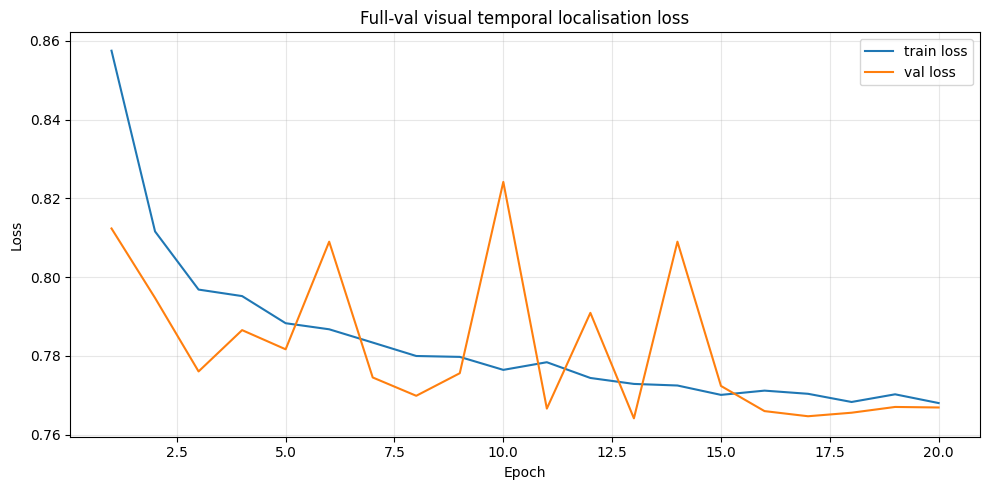

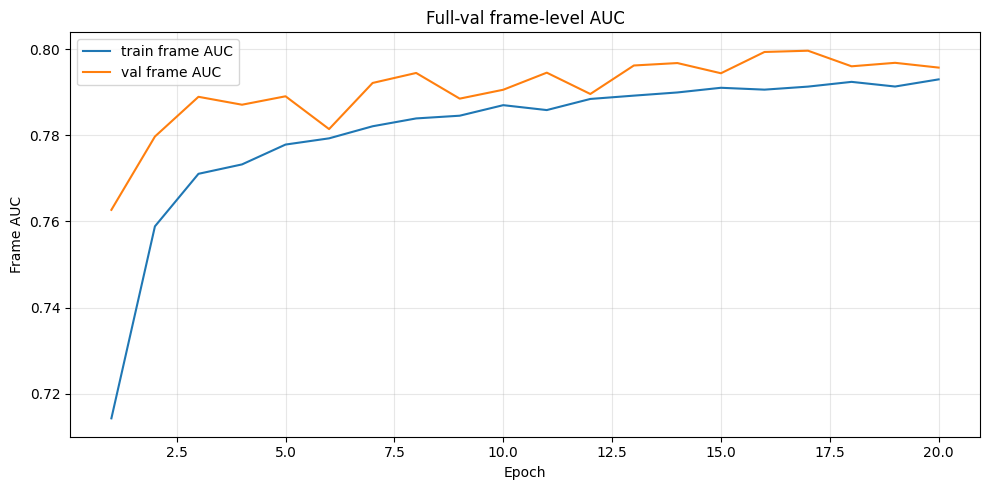

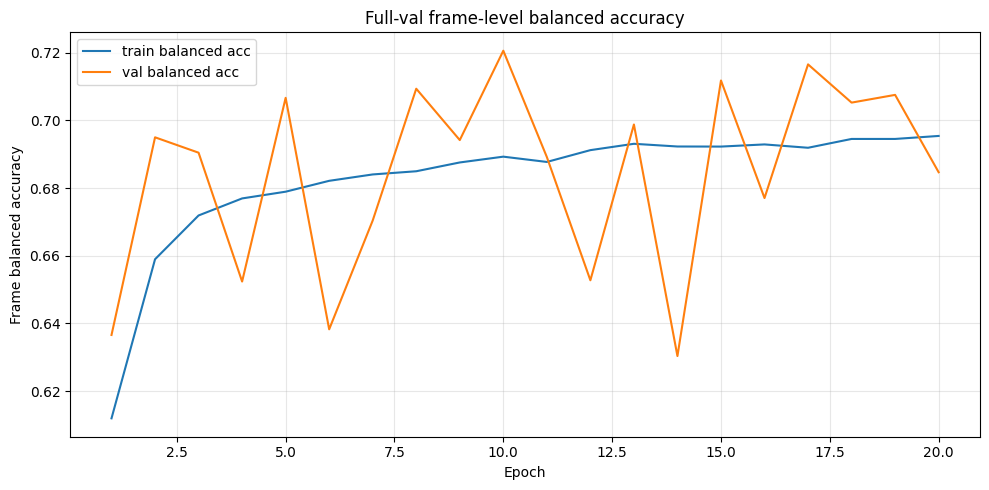

In [28]:
# training curves from the saved full-val history csv

history_df = pd.read_csv(RESULTS_DIR / "temporal_training_history.csv")
display(history_df.tail())

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Full-val visual temporal localisation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "temporal_loss.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_frame_auc"], label="train frame AUC")
plt.plot(history_df["epoch"], history_df["val_frame_auc"], label="val frame AUC")
plt.xlabel("Epoch")
plt.ylabel("Frame AUC")
plt.title("Full-val frame-level AUC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "frame_auc.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_frame_balanced_accuracy"], label="train balanced acc")
plt.plot(history_df["epoch"], history_df["val_frame_balanced_accuracy"], label="val balanced acc")
plt.xlabel("Epoch")
plt.ylabel("Frame balanced accuracy")
plt.title("Full-val frame-level balanced accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "frame_balanced_accuracy.png", dpi=200)
plt.show()

## test evaluation

load the best validation-auc checkpoint and evaluate the held-out test frames.

the flat frame predictions are then grouped back into clips for max-pooled clip scores, sampled-grid iou and condition-level behaviour.

In [29]:
# load the best checkpoint and get probabilities for every sampled test frame

checkpoint_path = CHECKPOINT_DIR / "best_temporal_head.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

temporal_model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded:", checkpoint_path)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Val metrics:", checkpoint["val_metrics"])

test_frame_metrics, test_y_true, test_y_prob, test_repeated_indices, test_repeated_video_labels = evaluate_temporal_model(
    temporal_model,
    test_shard_paths,
    criterion,
    device,
    batch_size=TEMPORAL_BATCH_SIZE,
    threshold=DEFAULT_THRESHOLD,
)

test_frame_metrics_df = pd.DataFrame([{
    "threshold": DEFAULT_THRESHOLD,
    **test_frame_metrics,
}])

test_frame_metrics_path = RESULTS_DIR / "test_frame_metrics.csv"
test_frame_metrics_df.to_csv(test_frame_metrics_path, index=False)

display(test_frame_metrics_df)
print("Saved:", test_frame_metrics_path)

Loaded: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/checkpoints/best_temporal_head.pt
Checkpoint epoch: 17
Val metrics: {'loss': 0.7646642754813588, 'frame_accuracy': 0.8246662151702786, 'frame_balanced_accuracy': 0.7165688136406705, 'frame_f1': 0.15013156866321029, 'frame_precision': 0.08574702210450348, 'frame_recall': 0.6026143790849673, 'frame_auc': 0.7996082971678677}


,threshold,loss,frame_accuracy,frame_balanced_accuracy,frame_f1,frame_precision,frame_recall,frame_auc
0,0.5,0.774497,0.823786,0.715632,0.150783,0.086194,0.601545,0.795657


Saved: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/results/test_frame_metrics.csv


In [30]:
# save one row per sampled test frame and join the clip metadata back on

test_frame_predictions_df = pd.DataFrame({
    "row_index": test_repeated_indices,
    "frame_true": test_y_true,
    "frame_prob": test_y_prob,
})

test_frame_predictions_df["frame_pred"] = (test_frame_predictions_df["frame_prob"] >= DEFAULT_THRESHOLD).astype(int)
test_frame_predictions_df["timestep"] = test_frame_predictions_df.groupby("row_index").cumcount()

test_meta = test_df.reset_index().rename(columns={"index": "row_index"})
meta_cols = [c for c in ["row_index", CONDITION_COL, "visual_fake", "audio_fake", "binary_label"] if c in test_meta.columns]

test_frame_predictions_df = test_frame_predictions_df.merge(
    test_meta[meta_cols],
    on="row_index",
    how="left",
)

frame_pred_path = RESULTS_DIR / "test_frame_predictions.csv"
test_frame_predictions_df.to_csv(frame_pred_path, index=False)

display(test_frame_predictions_df.head())
print("Saved:", frame_pred_path)

,row_index,frame_true,frame_prob,frame_pred,timestep,condition,visual_fake,audio_fake,binary_label
0,0,0,0.737164,1,0,fake_video_fake_audio,1,1,1
1,0,0,0.423892,0,1,fake_video_fake_audio,1,1,1
2,0,0,0.284510,0,2,fake_video_fake_audio,1,1,1
3,0,1,0.709604,1,3,fake_video_fake_audio,1,1,1
4,0,1,0.139228,0,4,fake_video_fake_audio,1,1,1


Saved: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/results/test_frame_predictions.csv


In [31]:
# group the 64 frame scores back into clips and calculate sampled-grid iou

clip_rows = []

for row_index, group in test_frame_predictions_df.groupby("row_index"):
    true_frames = group["frame_true"].values.astype(int)
    probs = group["frame_prob"].values

    pred_frames = (probs >= DEFAULT_THRESHOLD).astype(int)

    clip_true = int(true_frames.max() > 0)
    clip_prob_max = float(probs.max())
    clip_prob_mean = float(probs.mean())
    clip_pred = int(clip_prob_max >= DEFAULT_THRESHOLD)

    intersection = np.logical_and(true_frames == 1, pred_frames == 1).sum()
    union = np.logical_or(true_frames == 1, pred_frames == 1).sum()
    sampled_iou = float(intersection / union) if union > 0 else np.nan

    clip_rows.append({
        "row_index": int(row_index),
        "condition": group[CONDITION_COL].iloc[0],
        "visual_fake": int(group["visual_fake"].iloc[0]),
        "audio_fake": int(group["audio_fake"].iloc[0]),
        "binary_label": int(group["binary_label"].iloc[0]),
        "clip_true_visual_fake_from_frames": clip_true,
        "clip_pred_visual_fake": clip_pred,
        "clip_prob_max": clip_prob_max,
        "clip_prob_mean": clip_prob_mean,
        "positive_true_frames": int(true_frames.sum()),
        "positive_pred_frames": int(pred_frames.sum()),
        "sampled_frame_iou": sampled_iou,
    })

test_clip_predictions_df = pd.DataFrame(clip_rows)

clip_pred_path = RESULTS_DIR / "test_clip_predictions.csv"
test_clip_predictions_df.to_csv(clip_pred_path, index=False)

display(test_clip_predictions_df.head())
print("Saved:", clip_pred_path)

,row_index,condition,visual_fake,audio_fake,binary_label,clip_true_visual_fake_from_frames,clip_pred_visual_fake,clip_prob_max,clip_prob_mean,positive_true_frames,positive_pred_frames,sampled_frame_iou
0,0,fake_video_fake_audio,1,1,1,1,1,0.786334,0.362652,2,12,0.076923
1,1,fake_video_real_audio,1,0,1,1,1,0.736920,0.363908,2,12,0.000000
2,2,real,0,0,0,0,1,0.782333,0.458912,0,26,0.000000
3,3,real_video_fake_audio,0,1,1,0,1,0.786334,0.353613,0,11,0.000000
4,4,fake_video_fake_audio,1,1,1,1,0,0.341624,0.089868,2,0,0.000000


Saved: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/results/test_clip_predictions.csv


In [32]:
# clip-level view using the maximum sampled-frame probability

clip_true = test_clip_predictions_df["clip_true_visual_fake_from_frames"].values.astype(int)
clip_prob = test_clip_predictions_df["clip_prob_max"].values
clip_pred = test_clip_predictions_df["clip_pred_visual_fake"].values.astype(int)

clip_metrics = {
    "threshold": DEFAULT_THRESHOLD,
    "clip_accuracy": accuracy_score(clip_true, clip_pred),
    "clip_balanced_accuracy": balanced_accuracy_score(clip_true, clip_pred),
    "clip_f1": f1_score(clip_true, clip_pred, zero_division=0),
    "clip_precision": precision_score(clip_true, clip_pred, zero_division=0),
    "clip_recall": recall_score(clip_true, clip_pred, zero_division=0),
    "clip_auc": safe_auc(clip_true, clip_prob),
}

clip_metrics_df = pd.DataFrame([clip_metrics])
clip_metrics_path = RESULTS_DIR / "test_clip_metrics.csv"
clip_metrics_df.to_csv(clip_metrics_path, index=False)

display(clip_metrics_df)
print("Saved:", clip_metrics_path)

,threshold,clip_accuracy,clip_balanced_accuracy,clip_f1,clip_precision,clip_recall,clip_auc
0,0.5,0.58718,0.589706,0.665969,0.555297,0.831735,0.640474


Saved: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/results/test_clip_metrics.csv


In [33]:
# localisation summary on positive visual-fake clips only

positive_clips = test_clip_predictions_df[
    test_clip_predictions_df["clip_true_visual_fake_from_frames"] == 1
].copy()

localisation_metrics = {
    "n_positive_visual_fake_clips": len(positive_clips),
    "mean_sampled_frame_iou_positive_clips": float(positive_clips["sampled_frame_iou"].mean()) if len(positive_clips) else np.nan,
    "median_sampled_frame_iou_positive_clips": float(positive_clips["sampled_frame_iou"].median()) if len(positive_clips) else np.nan,
    "recall_iou_ge_0_1": float((positive_clips["sampled_frame_iou"] >= 0.1).mean()) if len(positive_clips) else np.nan,
    "recall_iou_ge_0_3": float((positive_clips["sampled_frame_iou"] >= 0.3).mean()) if len(positive_clips) else np.nan,
    "recall_iou_ge_0_5": float((positive_clips["sampled_frame_iou"] >= 0.5).mean()) if len(positive_clips) else np.nan,
}

localisation_metrics_df = pd.DataFrame([localisation_metrics])
localisation_metrics_path = RESULTS_DIR / "test_localisation_metrics.csv"
localisation_metrics_df.to_csv(localisation_metrics_path, index=False)

display(localisation_metrics_df)
print("Saved:", localisation_metrics_path)

,n_positive_visual_fake_clips,mean_sampled_frame_iou_positive_clips,median_sampled_frame_iou_positive_clips,recall_iou_ge_0_1,recall_iou_ge_0_3,recall_iou_ge_0_5
0,5735,0.245616,0.136364,0.567219,0.319268,0.212729


Saved: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/results/test_localisation_metrics.csv


In [34]:
# condition breakdown - audio-only fakes are the important visual shortcut check

condition_rows = []

for condition, frame_group in test_frame_predictions_df.groupby(CONDITION_COL):
    y_true = frame_group["frame_true"].values.astype(int)
    y_prob = frame_group["frame_prob"].values
    y_pred = frame_group["frame_pred"].values.astype(int)

    clip_group = test_clip_predictions_df[test_clip_predictions_df["condition"] == condition]

    condition_rows.append({
        "condition": condition,
        "n_videos": int(len(clip_group)),
        "n_frames": int(len(frame_group)),
        "true_positive_frame_rate": float(y_true.mean()),
        "predicted_positive_frame_rate": float(y_pred.mean()),
        "mean_frame_fake_probability": float(y_prob.mean()),
        "frame_accuracy": accuracy_score(y_true, y_pred),
        "frame_balanced_accuracy": balanced_accuracy_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan,
        "frame_f1": f1_score(y_true, y_pred, zero_division=0),
        "frame_precision": precision_score(y_true, y_pred, zero_division=0),
        "frame_recall": recall_score(y_true, y_pred, zero_division=0),
        "frame_auc": safe_auc(y_true, y_prob),
        "clip_predicted_visual_fake_rate": float(clip_group["clip_pred_visual_fake"].mean()) if len(clip_group) else np.nan,
        "clip_mean_max_probability": float(clip_group["clip_prob_max"].mean()) if len(clip_group) else np.nan,
        "mean_sampled_frame_iou": float(clip_group["sampled_frame_iou"].mean()) if len(clip_group) else np.nan,
    })

condition_metrics_df = pd.DataFrame(condition_rows).sort_values("condition")

condition_metrics_path = RESULTS_DIR / "condition_temporal_metrics.csv"
condition_metrics_df.to_csv(condition_metrics_path, index=False)

display(condition_metrics_df)
print("Saved:", condition_metrics_path)

,condition,n_videos,n_frames,true_positive_frame_rate,predicted_positive_frame_rate,mean_frame_fake_probability,frame_accuracy,frame_balanced_accuracy,frame_f1,frame_precision,frame_recall,frame_auc,clip_predicted_visual_fake_rate,clip_mean_max_probability,mean_sampled_frame_iou
0,fake_video_fake_audio,2890,184960,0.050378,0.189144,0.304624,0.820750,0.715377,0.251636,0.15933,0.598197,0.795340,0.834256,0.687073,0.241745
1,fake_video_real_audio,2871,183744,0.054282,0.197775,0.307801,0.813588,0.715126,0.260440,0.16596,0.604672,0.796292,0.828979,0.691037,0.247711
2,real,2987,191168,0.000000,0.174925,0.295947,0.825075,NaN,0.000000,0.00000,0.000000,NaN,0.659190,0.588126,0.000000
3,real_video_fake_audio,2843,181952,0.000000,0.164186,0.290907,0.835814,NaN,0.000000,0.00000,0.000000,NaN,0.643686,0.581398,0.000000


Saved: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/results/condition_temporal_metrics.csv


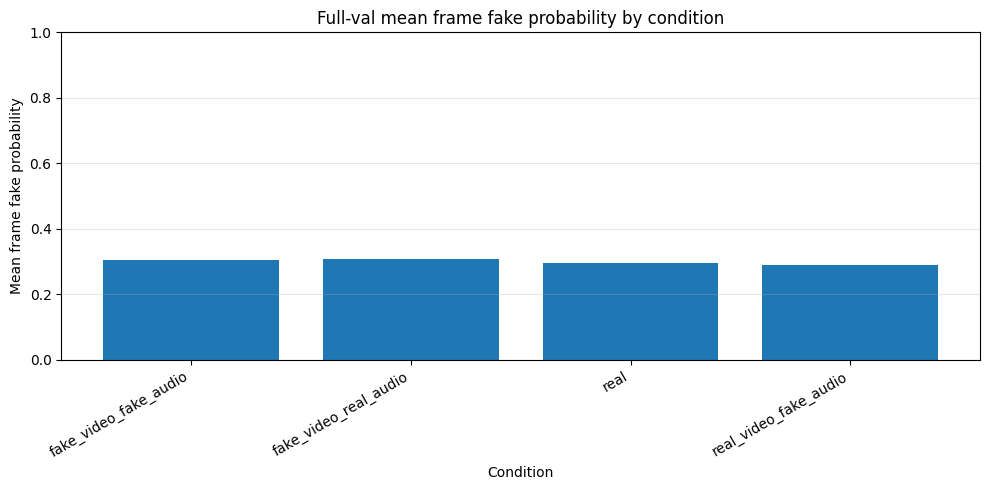

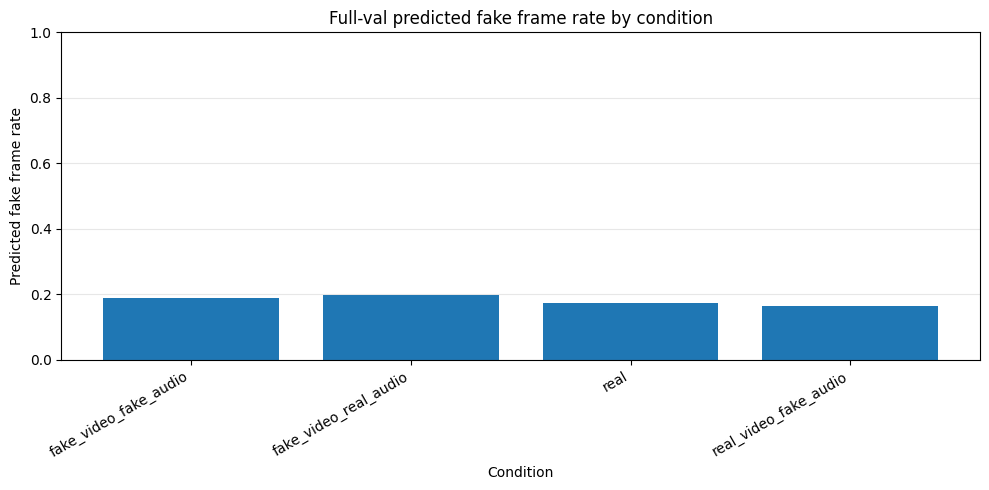

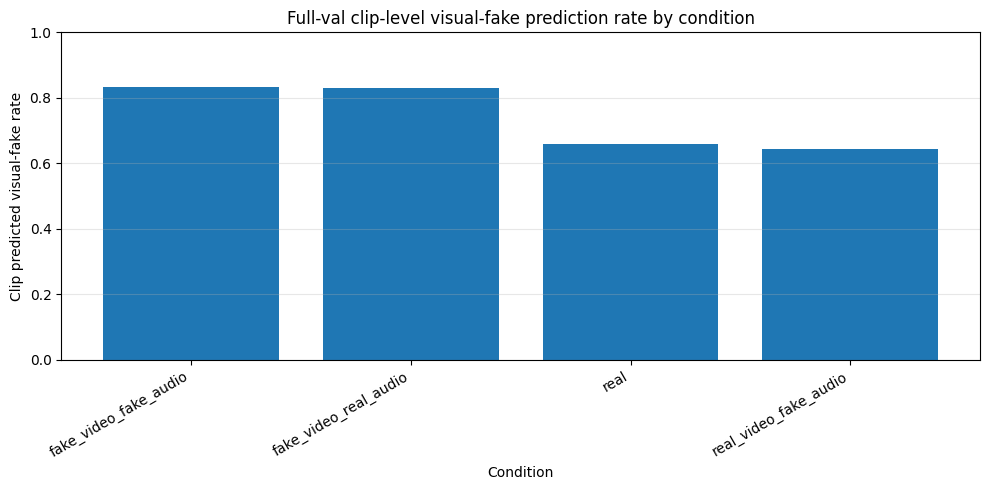

In [35]:
# condition plots from the saved full-val test predictions

plt.figure(figsize=(10, 5))
plt.bar(condition_metrics_df["condition"], condition_metrics_df["mean_frame_fake_probability"])
plt.xlabel("Condition")
plt.ylabel("Mean frame fake probability")
plt.title("Full-val mean frame fake probability by condition")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "condition_mean_frame_fake_probability.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(condition_metrics_df["condition"], condition_metrics_df["predicted_positive_frame_rate"])
plt.xlabel("Condition")
plt.ylabel("Predicted fake frame rate")
plt.title("Full-val predicted fake frame rate by condition")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "condition_predicted_positive_frame_rate.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(condition_metrics_df["condition"], condition_metrics_df["clip_predicted_visual_fake_rate"])
plt.xlabel("Condition")
plt.ylabel("Clip predicted visual-fake rate")
plt.title("Full-val clip-level visual-fake prediction rate by condition")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "condition_clip_visual_fake_rate.png", dpi=200)
plt.show()

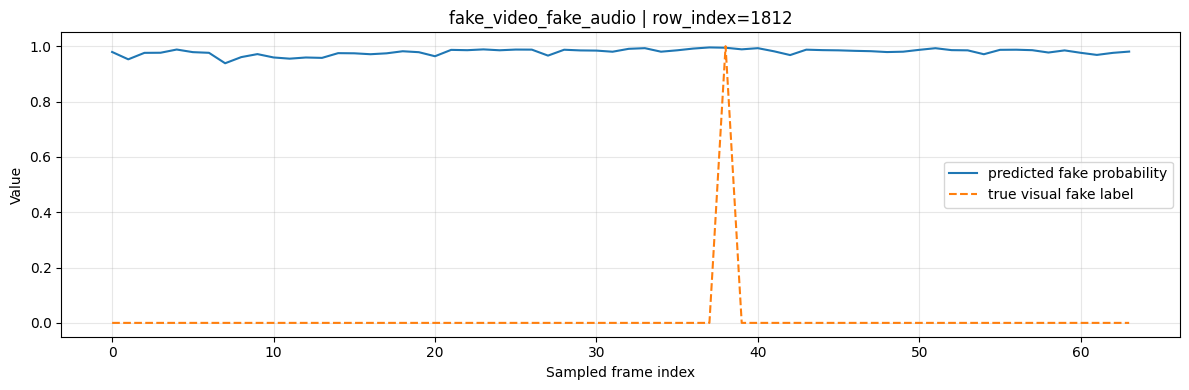

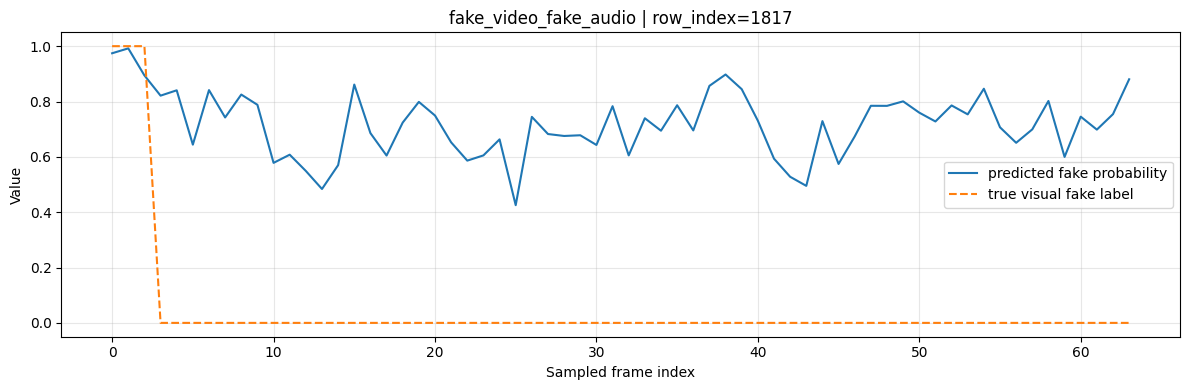

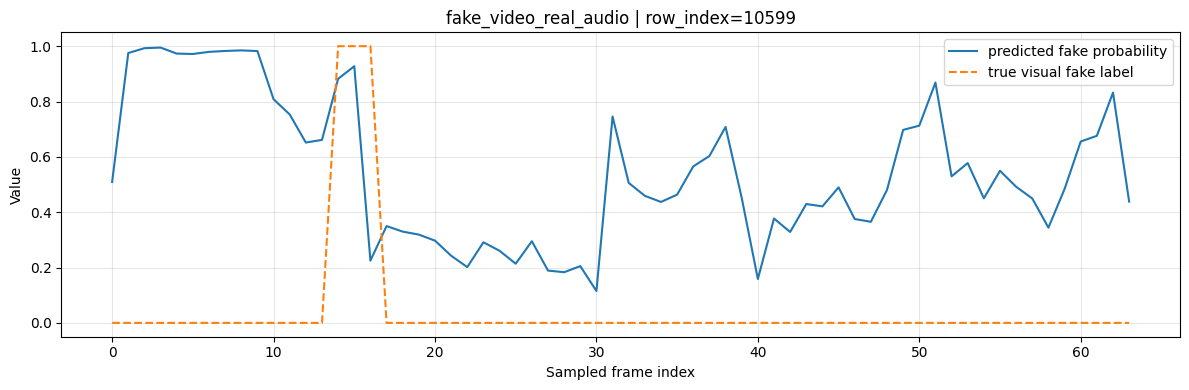

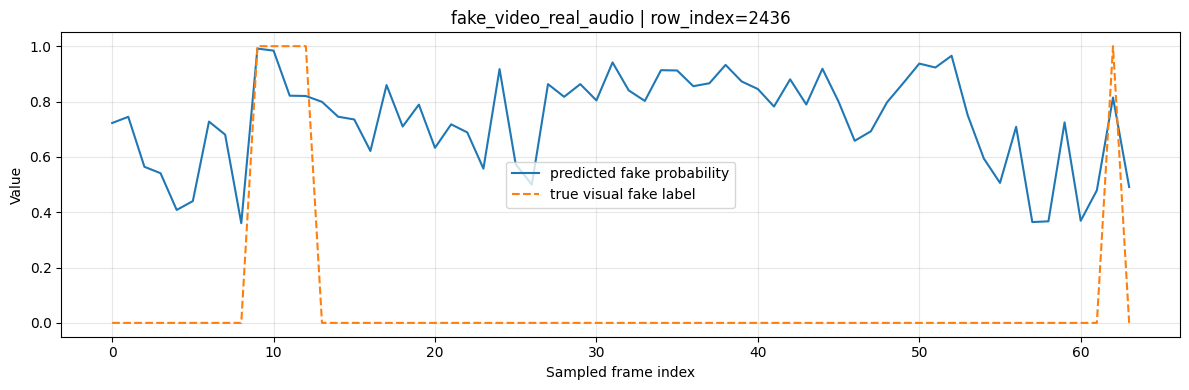

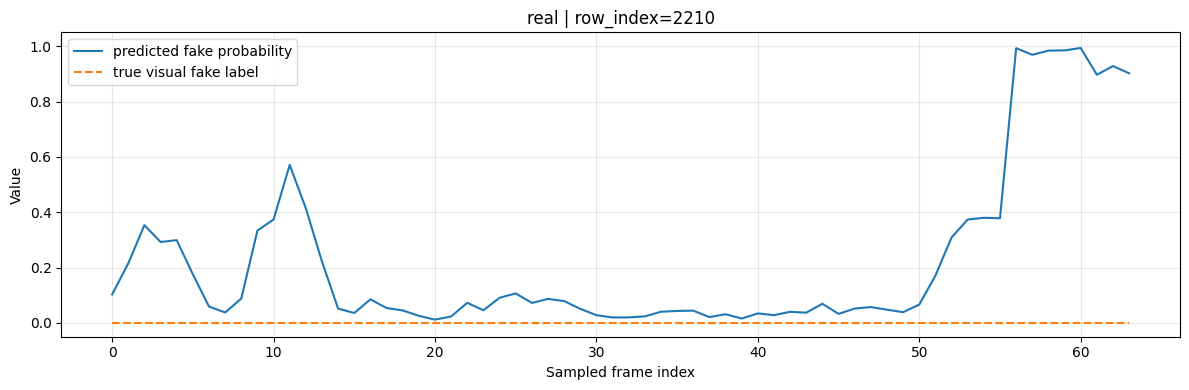

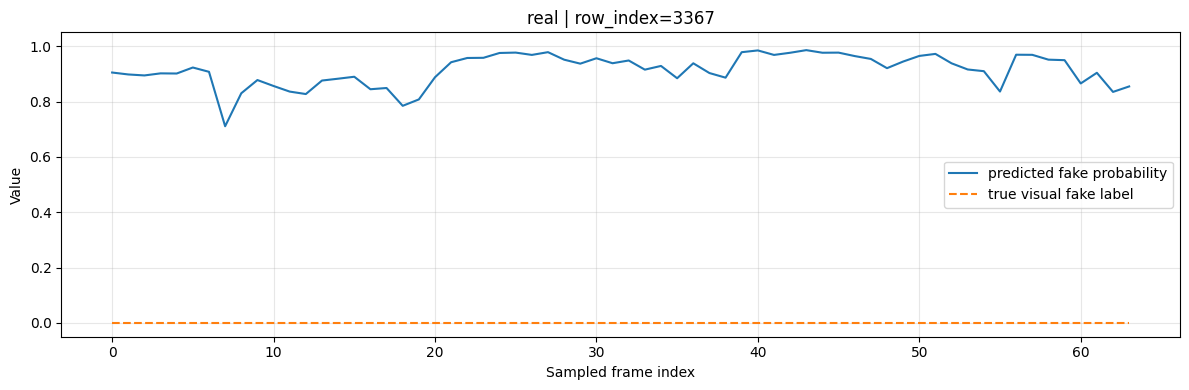

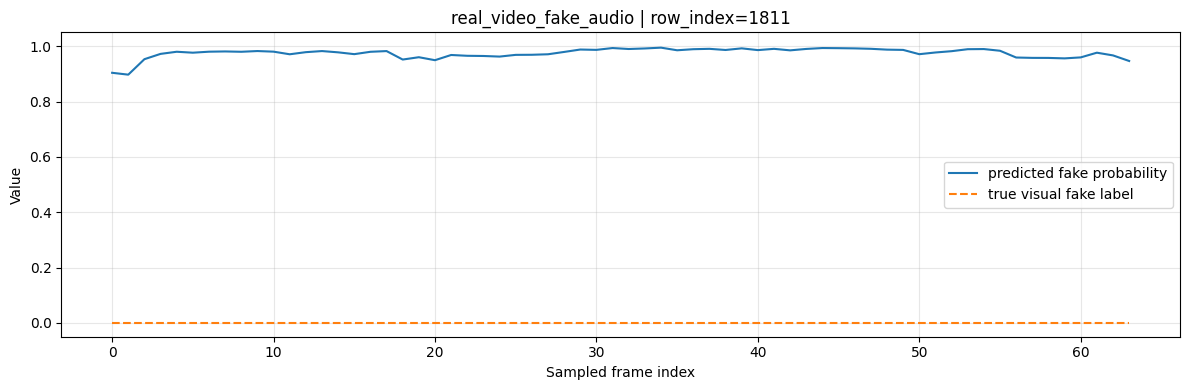

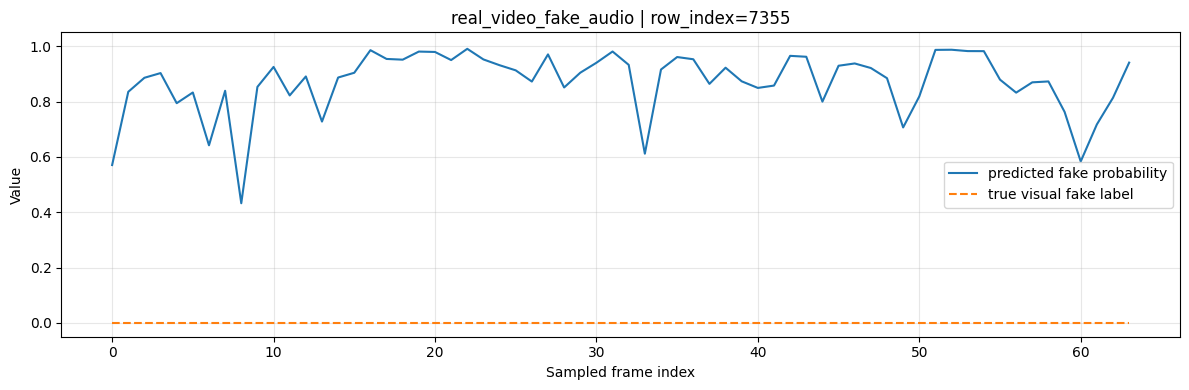

In [36]:
# show a couple of high-scoring temporal examples from each condition

for cond in sorted(test_frame_predictions_df[CONDITION_COL].dropna().unique()):
    plot_temporal_examples(test_frame_predictions_df, test_clip_predictions_df, cond, PLOTS_DIR, n_examples=2)

## validation threshold check

0.5 is the fixed threshold used for the main sampled-grid localisation view.

separately, i search validation probabilities for the frame threshold with the best balanced accuracy and then apply that selected threshold once to the test frame probabilities.

In [37]:
# search validation thresholds from 0.05 to 0.95 using frame balanced accuracy

val_frame_metrics_default, val_y_true, val_y_prob, val_repeated_indices, val_repeated_video_labels = evaluate_temporal_model(
    temporal_model,
    val_shard_paths,
    criterion,
    device,
    batch_size=TEMPORAL_BATCH_SIZE,
    threshold=DEFAULT_THRESHOLD,
)

threshold_rows = []

for t in np.linspace(0.05, 0.95, 181):
    pred = (val_y_prob >= t).astype(int)

    threshold_rows.append({
        "threshold": float(t),
        "frame_accuracy": accuracy_score(val_y_true, pred),
        "frame_balanced_accuracy": balanced_accuracy_score(val_y_true, pred),
        "frame_f1": f1_score(val_y_true, pred, zero_division=0),
        "frame_precision": precision_score(val_y_true, pred, zero_division=0),
        "frame_recall": recall_score(val_y_true, pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.sort_values("frame_balanced_accuracy", ascending=False).iloc[0]
best_threshold = float(best_threshold_row["threshold"])

threshold_path = RESULTS_DIR / "validation_threshold_search.csv"
threshold_df.to_csv(threshold_path, index=False)

display(best_threshold_row)
print("Best validation threshold:", best_threshold)
print("Saved:", threshold_path)

threshold                  0.390000
frame_accuracy             0.715365
frame_balanced_accuracy    0.729152
frame_f1                   0.118392
frame_precision            0.064316
frame_recall               0.743686
Name: 68, dtype: float64

Best validation threshold: 0.38999999999999996
Saved: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/results/validation_threshold_search.csv


In [38]:
# apply the validation-selected threshold to the existing test probabilities

tuned_pred = (test_y_prob >= best_threshold).astype(int)

tuned_test_frame_metrics = {
    "threshold": best_threshold,
    "frame_accuracy": accuracy_score(test_y_true, tuned_pred),
    "frame_balanced_accuracy": balanced_accuracy_score(test_y_true, tuned_pred),
    "frame_f1": f1_score(test_y_true, tuned_pred, zero_division=0),
    "frame_precision": precision_score(test_y_true, tuned_pred, zero_division=0),
    "frame_recall": recall_score(test_y_true, tuned_pred, zero_division=0),
    "frame_auc": safe_auc(test_y_true, test_y_prob),
}

tuned_test_frame_metrics_df = pd.DataFrame([tuned_test_frame_metrics])
tuned_metrics_path = RESULTS_DIR / "test_frame_metrics_threshold_tuned.csv"
tuned_test_frame_metrics_df.to_csv(tuned_metrics_path, index=False)

display(tuned_test_frame_metrics_df)
print("Saved:", tuned_metrics_path)

,threshold,frame_accuracy,frame_balanced_accuracy,frame_f1,frame_precision,frame_recall,frame_auc
0,0.39,0.714861,0.724293,0.118114,0.064223,0.734242,0.795657


Saved: /home/jovyan/MSC_PROJECT/experiments/exp006_visual_temporal_fullval/results/test_frame_metrics_threshold_tuned.csv


## exp004 vs exp006 reminder

this comparison is useful for seeing behaviour on a larger/natural distribution, but i should not describe it as a clean one-variable ablation.

exp006 changes the split/distribution and uses the full usable validation set, so differences can come from those changes rather than only model behaviour.

In [ ]:
# save the comparison notes beside the run outputs

comparison_notes = f'''# Balanced vs full-validation visual temporal comparison

## Balanced experiment

`exp004_visual_temporal_bal40k`

- controlled balanced subset
- same visual temporal target
- useful for clean method comparison

## Full-validation experiment

`{RUN_NAME}`

- full usable validation manifest
- group-disjoint split created from all available rows
- no class balancing or downsampling
- more realistic natural condition distribution

## Important reporting point

The full validation set is imbalanced for generic binary video labels, because all manipulated-modality cases count as fake.

However, visual temporal localisation uses a modality-specific target:

- `fake_video_real_audio` and `fake_video_fake_audio` are visual-positive
- `real` and `real_video_fake_audio` are visual-negative

So report binary-label imbalance separately from visual-target imbalance.

## Recommended comparison metrics

Use:

- frame-level AUC
- frame-level balanced accuracy
- threshold-tuned balanced accuracy
- clip-level AUC using max frame probability
- mean sampled-frame IoU
- condition-level predicted fake frame rate

Do not rely only on raw accuracy.
'''

comparison_notes_path = RUN_DIRS["run"] / "balanced_vs_fullval_notes.md"
comparison_notes_path.write_text(comparison_notes, encoding="utf-8")

print("Saved:", comparison_notes_path)

In [ ]:
# save a short text summary beside the run outputs

run_notes = "# " + RUN_NAME + " run notes\n\n"
run_notes += "## Purpose\n\nVisual temporal localisation on the full usable validation set with no balancing/downsampling.\n\n"
run_notes += "## Key methodological point\n\n"
run_notes += "This uses frame-level visual manipulation labels derived from condition and `" + SEGMENT_COL + "`.\n\n"
run_notes += "## Full-validation motivation\n\n"
run_notes += "This experiment evaluates the model under a larger, more natural validation-set distribution and can be compared against the balanced 40k experiment.\n\n"
run_notes += "## Important condition logic\n\n"
run_notes += "- real: all visual frame labels should be 0\n"
run_notes += "- real_video_fake_audio: all visual frame labels should be 0\n"
run_notes += "- fake_video_real_audio: visual fake frames from segment labels\n"
run_notes += "- fake_video_fake_audio: visual fake frames from segment labels\n\n"
run_notes += "## Shortcut analysis\n\n"
run_notes += "The most important shortcut check is predicted fake frame rate for `real_video_fake_audio`.\n\n"
run_notes += "## Config\n\n```json\n"
run_notes += json.dumps(EXPERIMENT_CONFIG, indent=2)
run_notes += "\n```\n\n"
run_notes += "## Source manifest\n\n" + str(manifest_path) + "\n\n"
run_notes += "## Metadata path used\n\n" + (str(metadata_path) if metadata_path is not None else "None") + "\n\n"
run_notes += "## Snapshot warning\n\n"
run_notes += "The final notebook snapshot only copies:\n" + str(NOTEBOOK_PATH) + "\n"
run_notes += "The notebook had to be saved before the snapshot helper copied it.\n"

run_notes_path = RUN_DIRS["run"] / "run_notes.md"
run_notes_path.write_text(run_notes, encoding="utf-8")

print("Saved:", run_notes_path)

In [ ]:
# old helper used to copy the saved notebook into the run folder

def save_final_notebook_snapshot(notebook_path, run_dirs):
    """copy the saved notebook file into the experiment snapshot folder."""
    notebook_path = Path(notebook_path)
    snapshot_dir = Path(run_dirs["notebook"])
    snapshot_dir.mkdir(parents=True, exist_ok=True)

    if not notebook_path.exists():
        raise FileNotFoundError(
            f"Notebook path does not exist: {notebook_path}\n"
            f"Save this notebook as {notebook_path} first, then rerun this cell."
        )

    if notebook_path.name != NOTEBOOK_FILENAME:
        raise ValueError(
            f"Refusing to snapshot unexpected notebook name: {notebook_path.name}\n"
            f"Expected: {NOTEBOOK_FILENAME}"
        )

    size_kb = notebook_path.stat().st_size / 1024
    if size_kb < 10:
        raise ValueError(f"Notebook file looks too small ({size_kb:.1f} KB). Refusing snapshot.")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    snapshot_path = snapshot_dir / f"final_snapshot_{timestamp}.ipynb"

    shutil.copy2(notebook_path, snapshot_path)

    snapshot_note = snapshot_dir / "snapshot_source.txt"
    snapshot_note.write_text(
        f"Snapshot created at: {datetime.now().isoformat(timespec='seconds')}\n"
        f"Source notebook: {notebook_path}\n"
        f"Snapshot path: {snapshot_path}\n"
        f"Source size KB: {size_kb:.1f}\n",
        encoding="utf-8",
    )

    print("Final notebook snapshot saved:", snapshot_path)
    print("Snapshot source note:", snapshot_note)

    return snapshot_path


# this copied whatever notebook version had actually been saved to disk
snapshot_path = save_final_notebook_snapshot(NOTEBOOK_PATH, RUN_DIRS)

In [ ]:
# make a csv index of the files produced by the run

def create_experiment_index(run_dirs):
    """list the run files, sizes and modification times in one csv."""
    run_dir = Path(run_dirs["run"])
    rows = []

    for section, folder in run_dirs.items():
        folder = Path(folder)
        if not folder.exists() or not folder.is_dir():
            continue

        for file in folder.rglob("*"):
            if not file.is_file():
                continue

            rows.append({
                "section": section,
                "filename": file.name,
                "path": str(file),
                "size_mb": file.stat().st_size / 1024**2,
                "modified_at": datetime.fromtimestamp(file.stat().st_mtime).isoformat(timespec="seconds"),
            })

    index_df = pd.DataFrame(rows).sort_values(["section", "path"])
    index_path = run_dir / "archive_index.csv"
    index_df.to_csv(index_path, index=False)

    print("Saved:", index_path)
    display(index_df)

    return index_df


experiment_index_df = create_experiment_index(RUN_DIRS)

In [ ]:
# build a smaller export zip with short internal paths

def safe_filename(name, max_len=60):
    """clean/shorten a filename before using it inside the export zip."""
    p = Path(name)
    stem = p.stem
    suffix = p.suffix

    safe = "".join(c if c.isalnum() or c in "._-" else "_" for c in stem).strip("_-.")

    if not safe:
        safe = "file"

    if len(safe) > max_len:
        h = hashlib.md5(safe.encode("utf-8")).hexdigest()[:8]
        safe = safe[:max_len - 9] + "_" + h

    return safe + suffix


def zip_experiment_shortpaths(
    run_dir,
    exports_dir,
    short_name,
    include_checkpoints=True,
    include_features=False,
    max_filename_len=60,
):
    """zip the run outputs while leaving out the large feature cache by default."""
    run_dir = Path(run_dir)
    exports_dir = Path(exports_dir)
    exports_dir.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    zip_path = exports_dir / f"{short_name}_{timestamp}.zip"

    mapping_rows = []

    folder_replacements = {
        "checkpoints": "ckpt",
        "manifests": "man",
        "results": "res",
        "plots": "plt",
        "notebook": "nb",
        "features": "feat",
    }

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for file in run_dir.rglob("*"):
            if not file.is_file():
                continue

            rel = file.relative_to(run_dir)

            if ".ipynb_checkpoints" in rel.parts:
                continue

            if not include_checkpoints and file.suffix in [".pt", ".pth", ".ckpt"]:
                continue

            if not include_features and "features" in rel.parts:
                continue

            parts = []
            for part in rel.parts[:-1]:
                parts.append(folder_replacements.get(part, safe_filename(part, max_len=30)))

            parts.append(safe_filename(rel.parts[-1], max_len=max_filename_len))

            arcname = Path(short_name, *parts)

            zipf.write(file, arcname=str(arcname))

            mapping_rows.append({
                "original_path": str(file),
                "archive_path": str(arcname),
            })

        mapping_df = pd.DataFrame(mapping_rows)
        zipf.writestr(
            f"{short_name}/archive_path_mapping.csv",
            mapping_df.to_csv(index=False),
        )

    print("Created:", zip_path)
    print(f"Size: {zip_path.stat().st_size / 1024**2:.2f} MB")
    print("Features included:", include_features)

    return zip_path


zip_path = zip_experiment_shortpaths(
    run_dir=RUN_DIRS["run"],
    exports_dir=EXPORTS_DIR,
    short_name=RUN_NAME,
    include_checkpoints=True,
    include_features=False,
)

display(FileLink(str(zip_path)))

## result reminders

things i need to remember from exp006:

- this is the larger natural-distribution visual temporal run, not the balanced exp004 split
- 64 frozen convnext-base frame features are kept separately
- the head is layernorm + linear and has no explicit temporal context
- frame auc and sampled-grid iou measure different things; ranking can be decent while localisation overlap stays weak
- clip scores here are pooled from the temporal frame probabilities, not a separate clip classifier
- `real_video_fake_audio` is the main visual shortcut check because its visual target should be real
- the split is clip-group-disjoint, not identity-disjoint
- do not present exp004 vs exp006 as a clean ablation because the data distribution/split changed